# Modelo riguroso de rendimiento de café

Notebook reproducible para auditar datos, balancear **solo el entrenamiento** con SMOTENC, comparar modelos mediante backtesting temporal y evaluar una única vez el holdout 2024.

La clasificación estima **rendimiento alto respecto a un umbral histórico**. No estima rentabilidad, ROI ni éxito empresarial.

## 1. Resumen y alcance

El flujo desarrolla dos tareas complementarias: clasificación de rendimiento alto/bajo y regresión de toneladas por hectárea. La decisión final se somete a siete controles; si alguno falla, los artefactos quedan marcados como experimentales.

## 2. Configuración reproducible

Se fijan rutas, semilla y versiones. El notebook no instala paquetes, no usa internet y no solicita entradas manuales.

In [1]:
from pathlib import Path
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.production_pipeline import (
    CATEGORICAL_FEATURES,
    CLASS_TARGET,
    DATA_PATH,
    NUMERIC_FEATURES,
    OUTPUT_DIR,
    TARGET,
    add_high_yield_target,
    audit_dataset,
    load_dataset,
    run_production_pipeline,
    smotenc_class_counts,
    temporal_splits,
)

np.random.seed(42)
sns.set_theme(style="whitegrid")
print({"python": platform.python_version(), "semilla": 42, "raiz": str(ROOT)})

{'python': '3.12.10', 'semilla': 42, 'raiz': 'C:\\Users\\Visitante\\Documents\\Proyectos\\proyecto Ing Datos\\proyecto IngDatos'}


## 3. Carga del dataset

La unidad analítica esperada es `departamento + municipio + cultivo + anio`.

In [2]:
raw_data = load_dataset(DATA_PATH)
print(f"Filas: {len(raw_data):,} | Columnas: {raw_data.shape[1]} | Años: {raw_data.anio.min()}-{raw_data.anio.max()}")
display(raw_data.head(3))

Filas: 10,973 | Columnas: 48 | Años: 2007-2024


,departamento,municipio,cultivo,anio,fuente_eva,split,rendimiento_t_ha,score_confiabilidad,dato_copiado,lags_incompletos,...,magnesio_meq_variabilidad,potasio_meq_variabilidad,salinidad_ds_m_variabilidad,tendencia_ph,tendencia_materia_organica_pct,tendencia_fosforo_ppm,tendencia_calcio_meq,tendencia_magnesio_meq,tendencia_potasio_meq,tendencia_salinidad_ds_m
0,ANTIOQUIA,ABEJORRAL,CAFE,2007,historica,historial,0.609846,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
1,ANTIOQUIA,ABEJORRAL,CAFE,2008,historica,historial,0.561931,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394
2,ANTIOQUIA,ABEJORRAL,CAFE,2009,historica,historial,0.562042,0.86,0,1,...,0.538478,0.209378,0.148821,-0.007361,0.25924,-0.079623,-0.079774,0.626093,0.34504,0.418394


## 4. Auditoría de calidad y leakage

La ejecución se detiene ante llaves duplicadas, target nulo, años faltantes o inconsistencias del lag de un año. `score_confiabilidad` y `dato_copiado` se excluyen porque dependen del target.

In [3]:
audit = audit_dataset(raw_data)
display(pd.DataFrame({
    "control": ["Filas", "Llaves duplicadas", "Target nulo", "Comparaciones lag", "Coincidencias lag"],
    "resultado": [audit["rows"], audit["duplicate_keys"], audit["target_nulls"], audit["lag_comparisons"], audit["lag_matches"]],
}))
display(pd.Series(audit["missing_percent"], name="faltante_pct").sort_values(ascending=False).head(15).to_frame())
print("Variables excluidas por leakage:", ", ".join(audit["excluded_leakage_columns"]))

,control,resultado
0,Filas,10973
1,Llaves duplicadas,0
2,Target nulo,0
3,Comparaciones lag,10215
4,Coincidencias lag,10215


,faltante_pct
fosforo_ppm_variabilidad,32.042286
salinidad_ds_m_variabilidad,31.878247
calcio_meq_variabilidad,31.878247
magnesio_meq_variabilidad,31.878247
ph_variabilidad,31.878247
potasio_meq_variabilidad,31.878247
materia_organica_pct_variabilidad,31.878247
fosforo_ppm_media,23.402898
salinidad_ds_m_media,22.974574
num_muestras_suelo,22.810535


Variables excluidas por leakage: score_confiabilidad, dato_copiado


## 5. Exploración inicial

Se observan distribución, evolución anual y faltantes antes de transformar datos. Las unidades del target son toneladas por hectárea.

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
sns.histplot(raw_data[TARGET], bins=35, kde=True, color="#2f6f4e", ax=axes[0])
axes[0].set(title="Rendimiento inicial (2007-2024)", xlabel="t/ha", ylabel="Observaciones")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.boxplot(data=raw_data, x="anio", y=TARGET, color="#8eb69b", fliersize=1, ax=axes[1])
axes[1].set(title="Rendimiento por año", xlabel="Año", ylabel="t/ha")
axes[1].tick_params(axis="x", rotation=65)
missing = raw_data.isna().mean().mul(100).sort_values(ascending=False).head(12)
sns.barplot(x=missing.values, y=missing.index, color="#a44a3f", ax=axes[2])
axes[2].set(title="Variables con más faltantes", xlabel="Faltante (%)", ylabel="Variable")
plt.tight_layout()
plt.show()

C:\Users\Visitante\AppData\Local\Temp\ipykernel_39040\1519011068.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Target y balance inicial

El umbral se calcula con la mediana observada hasta 2018 y queda congelado antes de los años de selección y holdout.

In [5]:
data, high_yield_threshold = add_high_yield_target(raw_data)
balance_initial = data.groupby("anio")[CLASS_TARGET].agg(["count", "sum", "mean"])
balance_initial["clase_alta_pct"] = balance_initial["mean"] * 100
print(f"Umbral histórico congelado: {high_yield_threshold:.6f} t/ha")
display(balance_initial[["count", "sum", "clase_alta_pct"]].round(2))
balance_initial["clase_alta_pct"].plot(kind="bar", figsize=(11, 4), color="#4d9078", title="Clase de rendimiento alto por año")
plt.axhline(50, linestyle="--", color="#a44a3f")
plt.ylabel("Clase alta (%)")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

Umbral histórico congelado: 0.923337 t/ha


,count,sum,clase_alta_pct
anio,,,
2007,590,282,47.80
2008,583,254,43.57
2009,608,240,39.47
2010,617,291,47.16
2011,625,222,35.52
2012,599,230,38.40
2013,596,151,25.34
2014,595,176,29.58
2015,595,470,78.99


C:\Users\Visitante\AppData\Local\Temp\ipykernel_39040\3945979063.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Features y separación temporal

Los modelos usan geografía conocida y variables históricas rezagadas. No se usa una división aleatoria.

In [6]:
splits = temporal_splits(data)
display(pd.DataFrame({
    "periodo": ["Historia", "Selección", "Holdout"],
    "años": ["2007-2018", "2019-2023", "2024"],
    "filas": [len(splits["history"]), len(splits["selection"]), len(splits["holdout"])],
}))
print("Categóricas:", CATEGORICAL_FEATURES)
print("Numéricas estrictas:", NUMERIC_FEATURES)

,periodo,años,filas
0,Historia,2007-2018,6513
1,Selección,2019-2023,3079
2,Holdout,2024,623


Categóricas: ['departamento', 'municipio']
Numéricas estrictas: ['anio', 'lags_incompletos', 'rendimiento_lag_1', 'rendimiento_lag_2', 'rendimiento_lag_3', 'produccion_lag_1', 'area_cosechada_lag_1', 'area_sembrada_lag_1', 'media_rendimiento_3y', 'variabilidad_rendimiento_3y', 'tendencia_rendimiento_3y']


## 8. SMOTENC aplicado únicamente a entrenamiento

SMOTENC conoce cuáles columnas son categóricas. Se ajusta sobre 2007-2018 y las filas sintéticas nunca se mezclan con validación o 2024.

In [7]:
smote_snapshot = smotenc_class_counts(splits["history"])
display(smote_snapshot)
smote_snapshot.set_index("class_name")[["before", "after"]].plot(kind="bar", figsize=(8, 4), color=["#a44a3f", "#4d9078"])
plt.title("Clases antes y después de SMOTENC — train 2007-2018")
plt.xlabel("Clase")
plt.ylabel("Filas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,class_label,class_name,before,after
0,0,Rendimiento bajo,3223,3290
1,1,Rendimiento alto,3290,3290


C:\Users\Visitante\AppData\Local\Temp\ipykernel_39040\1345490603.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. Backtest de clasificadores

Cada año 2019-2023 se predice entrenando exclusivamente con años anteriores. Aquí se ejecuta el pipeline completo y se publican artefactos solo después de terminar todas las validaciones.

,model,is_challenger,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_mcc,mean_roc_auc,mean_pr_auc,mean_brier,mean_ece
1,lag1,False,0.7355,0.6675,0.7817,0.8337,0.7973,0.3552,0.6675,0.7610,0.2645,0.2645
0,catboost_weighted,True,0.7230,0.6422,0.7943,0.7750,0.7677,0.3187,0.7302,0.8401,0.2070,0.1498
6,random_forest_smotenc,True,0.7136,0.6365,0.7872,0.7890,0.7652,0.3108,0.7029,0.8252,0.1955,0.1311
5,random_forest_plain,True,0.7092,0.6331,0.7818,0.8000,0.7661,0.3088,0.7078,0.8286,0.1963,0.1406
3,logistic_smotenc,True,0.7151,0.6083,0.7242,0.9147,0.7978,0.2728,0.7345,0.8460,0.2003,0.1705
2,logistic_plain,True,0.6998,0.5896,0.7095,0.9302,0.7923,0.2439,0.7370,0.8472,0.2103,0.1880
4,majority,False,0.6640,0.5000,0.6640,1.0000,0.7847,0.0000,0.5000,0.6640,0.2447,0.1980


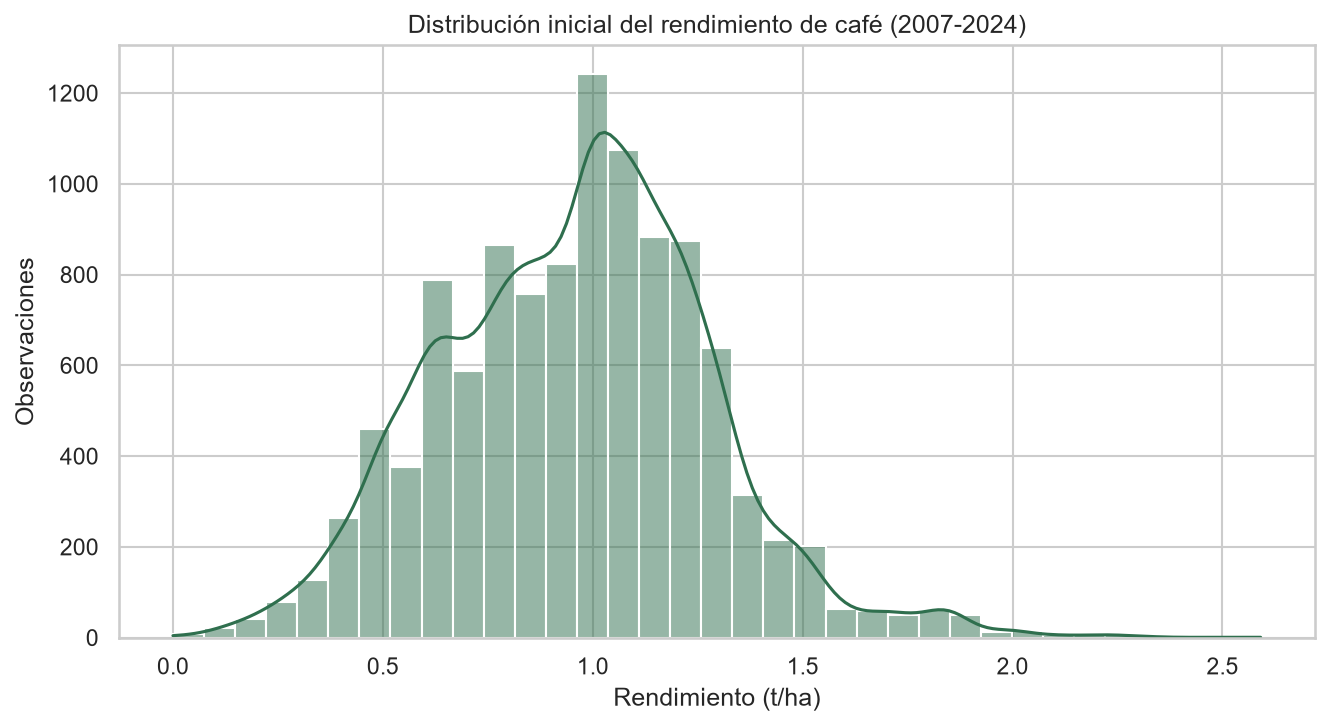

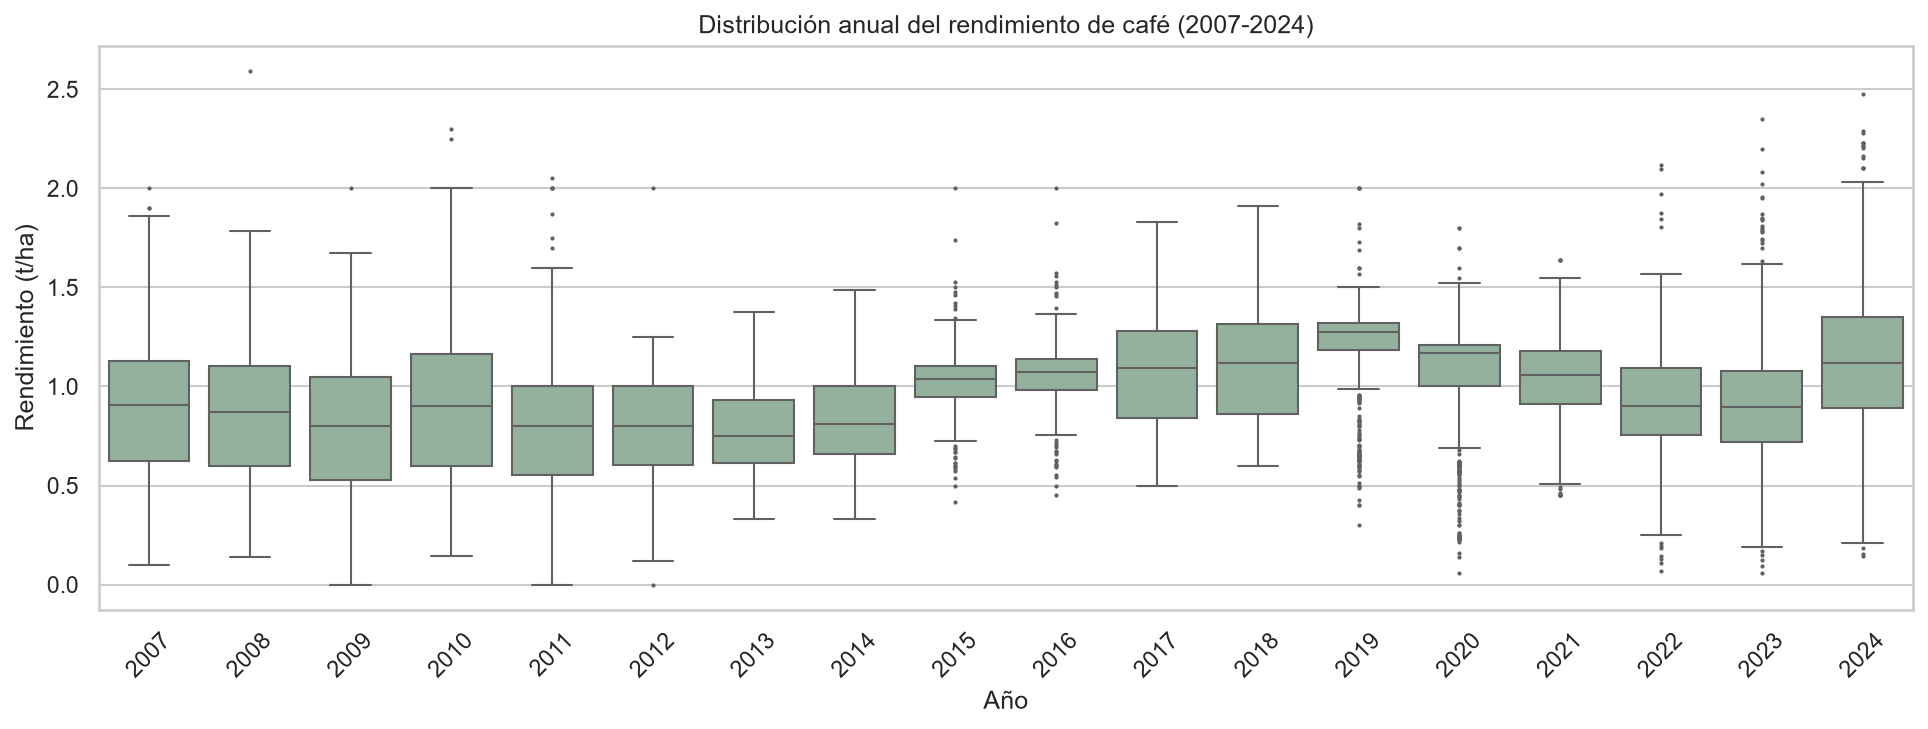

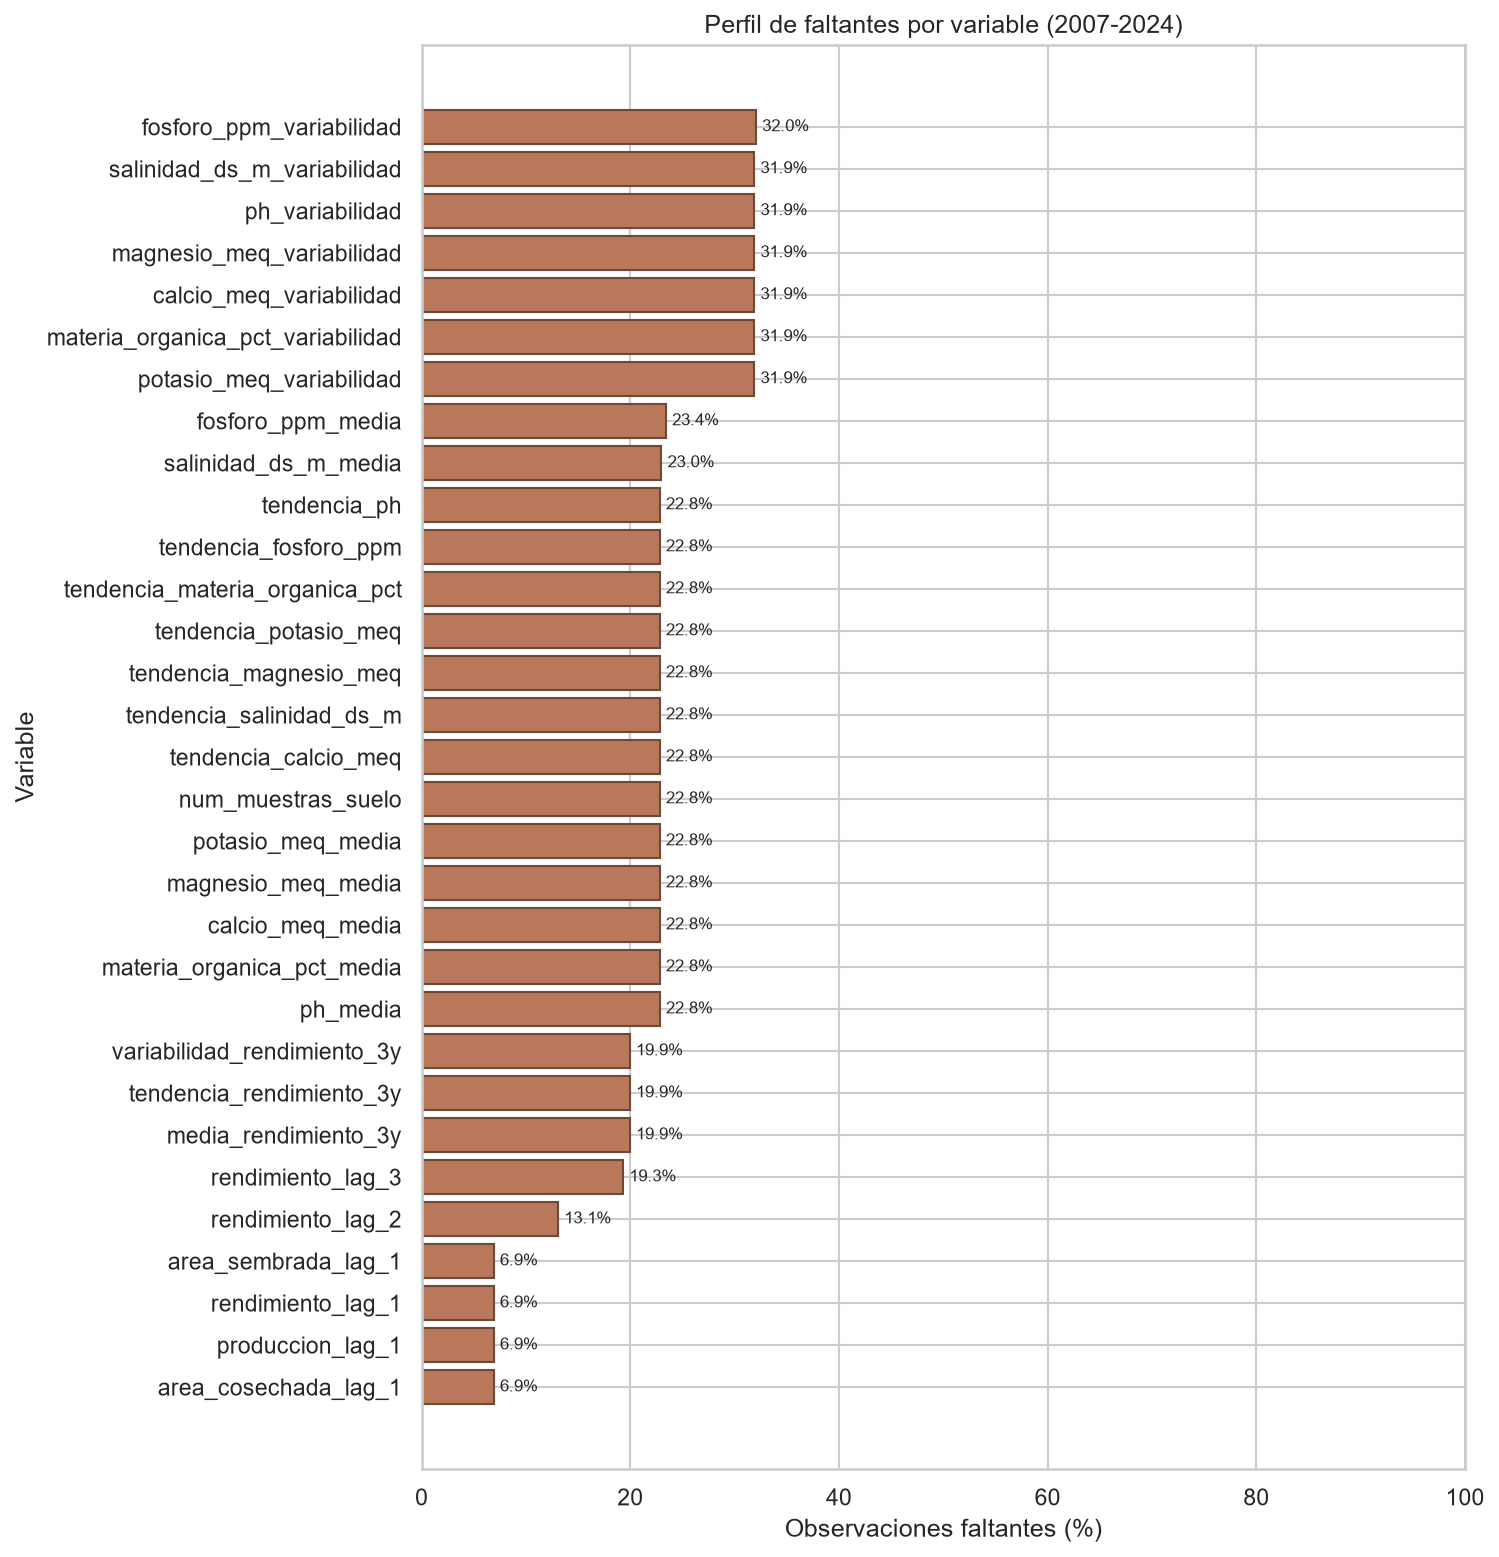

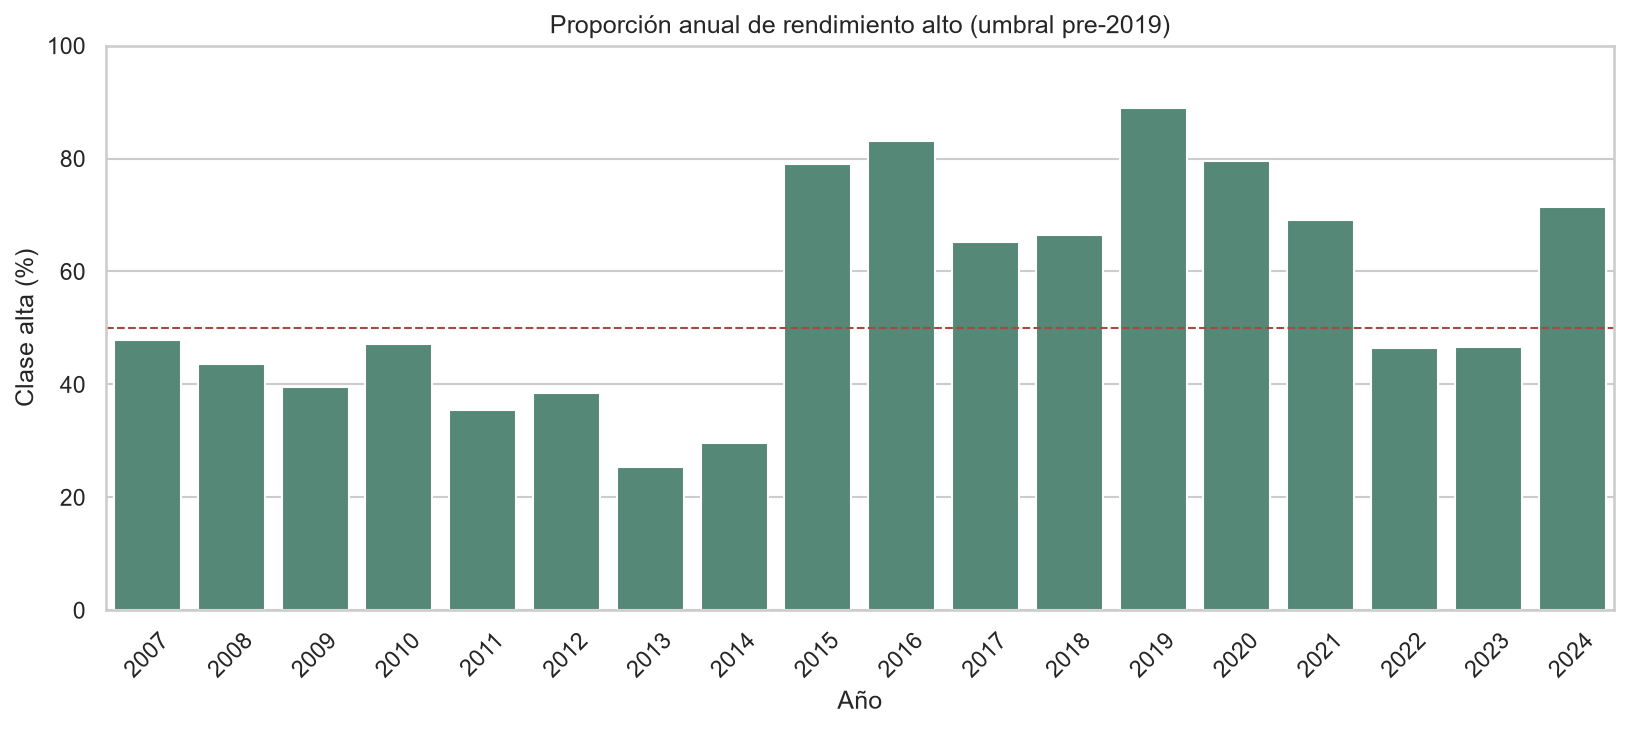

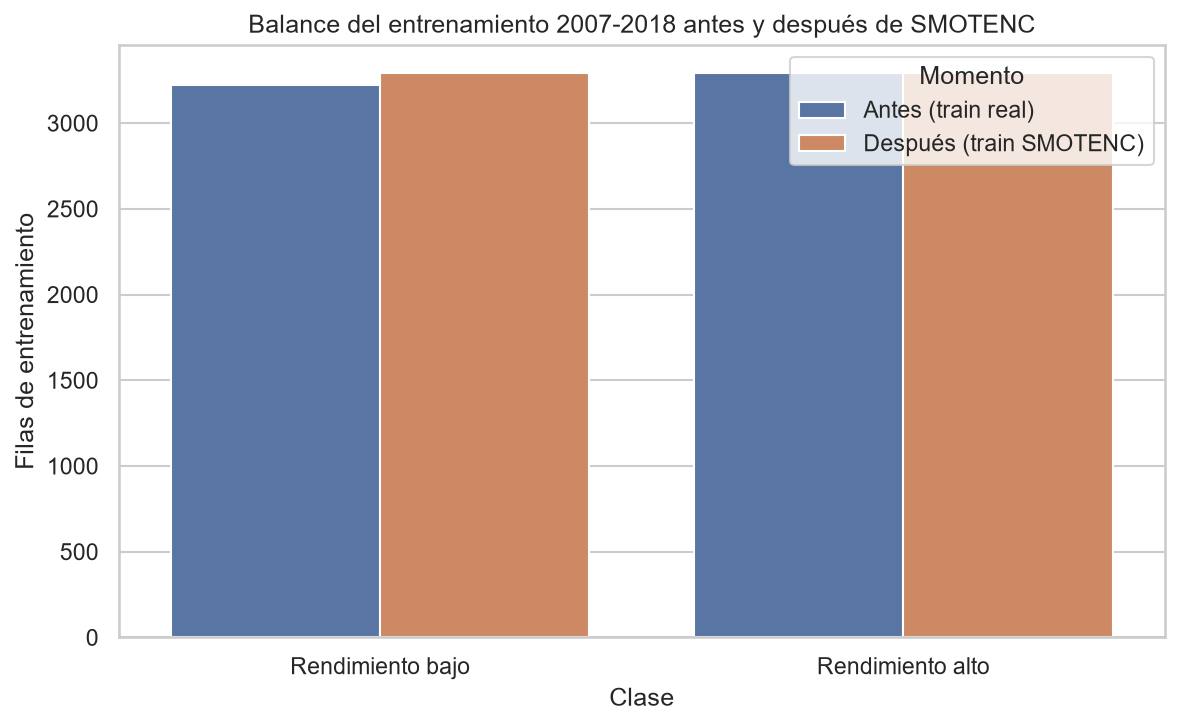

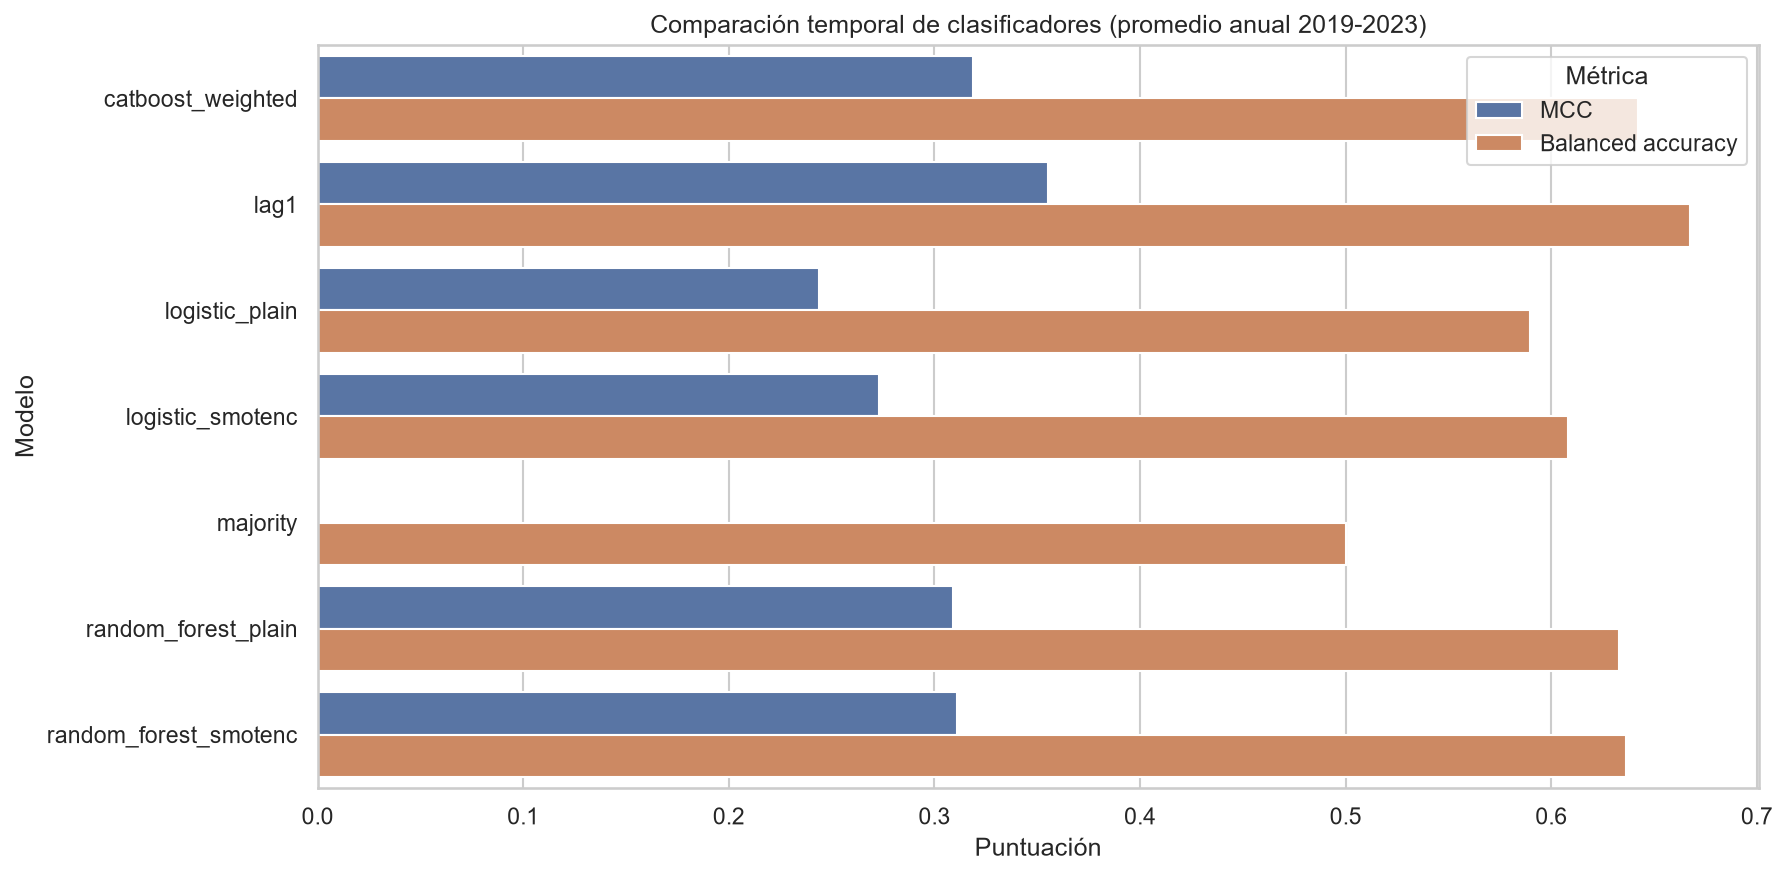

In [8]:
result = run_production_pipeline(DATA_PATH, OUTPUT_DIR)
manifest = result["manifest"]
display(result["classification_summary"].sort_values("mean_mcc", ascending=False).round(4))
for figure_name in [
    "01_distribucion_rendimiento.png", "02_boxplot_rendimiento_anio.png",
    "03_faltantes_variables.png", "04_balance_clase_anio.png",
    "05_smotenc_antes_despues.png", "06_modelos_mcc_balanced_accuracy.png",
]:
    display(Image(filename=str(OUTPUT_DIR / figure_name)))

## 10. Comparación y estabilidad anual

MCC es la métrica principal porque considera simultáneamente las cuatro celdas de la matriz de confusión y es más informativa ante desbalance.

,anio,mcc,balanced_accuracy,precision,recall
0,2019,0.1048,0.5804,0.9173,0.6853
1,2020,0.3603,0.6129,0.8371,0.9777
2,2021,0.2596,0.6134,0.7575,0.8670
3,2022,0.3936,0.6903,0.6140,0.8362
4,2023,0.4752,0.7139,0.8457,0.5086


Challenger seleccionado sin mirar 2024: catboost_weighted
Rango MCC anual: 0.105 a 0.475


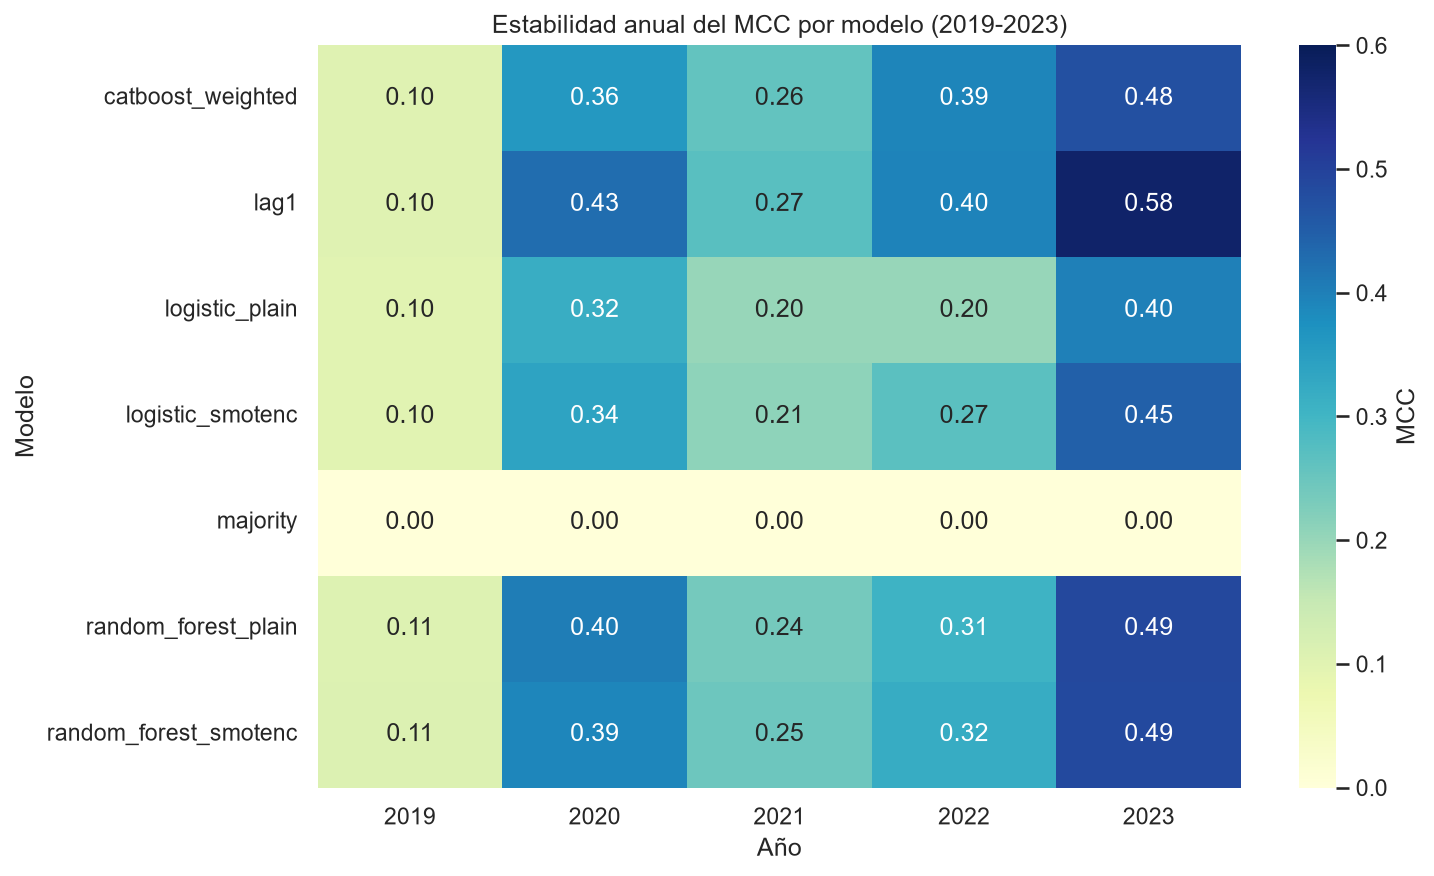

In [9]:
winner = manifest["classification"]["winner"]
winner_annual = result["classification_annual"].query("model == @winner")
display(winner_annual[["anio", "mcc", "balanced_accuracy", "precision", "recall"]].round(4))
print(f"Challenger seleccionado sin mirar 2024: {winner}")
print(f"Rango MCC anual: {winner_annual.mcc.min():.3f} a {winner_annual.mcc.max():.3f}")
display(Image(filename=str(OUTPUT_DIR / "07_mcc_anual.png")))

## 11. Selección, calibración y umbral congelado

El calibrador y el umbral usan únicamente predicciones fuera de muestra de 2019-2023. Ambos se congelan antes de evaluar 2024.

{'modelo': 'catboost_weighted', 'umbral_decision': 0.6699999999999999, 'umbral_rendimiento_t_ha': 0.9233366394115502}


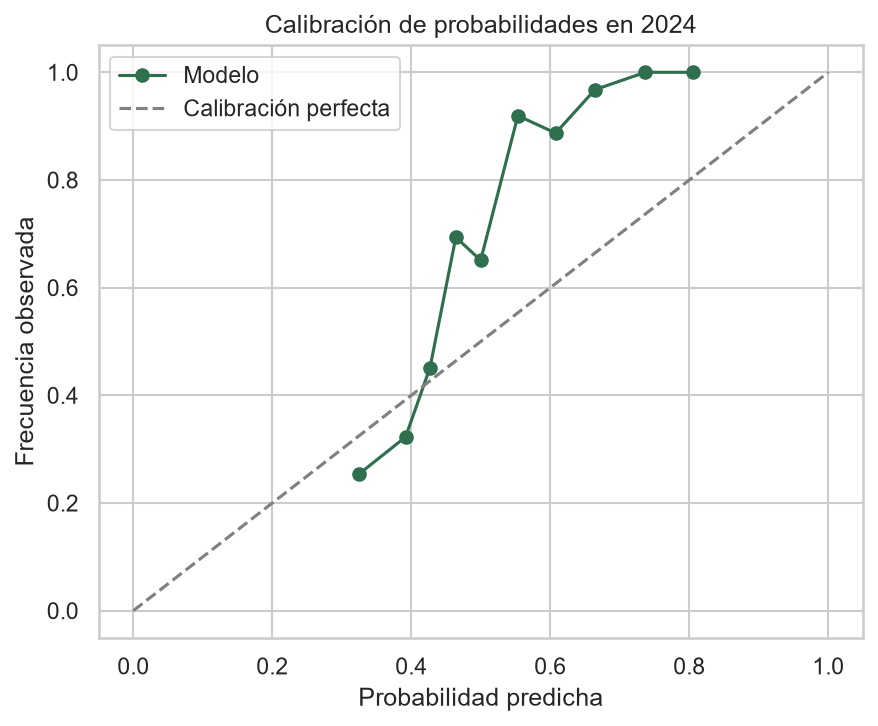

In [10]:
print({
    "modelo": winner,
    "umbral_decision": manifest["classification"]["decision_threshold"],
    "umbral_rendimiento_t_ha": manifest["targets"]["high_yield_threshold_t_ha"],
})
display(Image(filename=str(OUTPUT_DIR / "10_calibracion_2024.png")))

## 12. Holdout 2024 y matriz de confusión

2024 no participó en imputación, escalado, SMOTENC, selección, calibración ni elección del umbral. Filas: realidad; columnas: predicción.

,Predicho bajo,Predicho alto
Real bajo,176,2
Real alto,300,145


,2024
accuracy,0.5152
balanced_accuracy,0.6573
precision,0.9864
recall,0.3258
f1,0.4899
mcc,0.3347
roc_auc,0.8649
pr_auc,0.9443
brier,0.1795
ece,0.1933


Lectura crítica: 300 rendimientos altos quedaron clasificados como bajos y 2 bajos como altos.


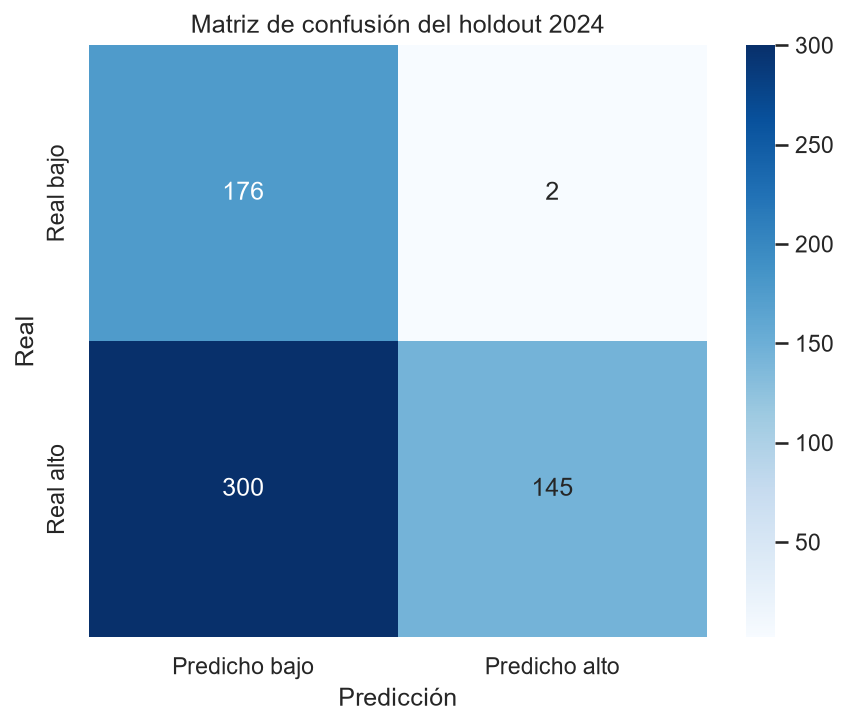

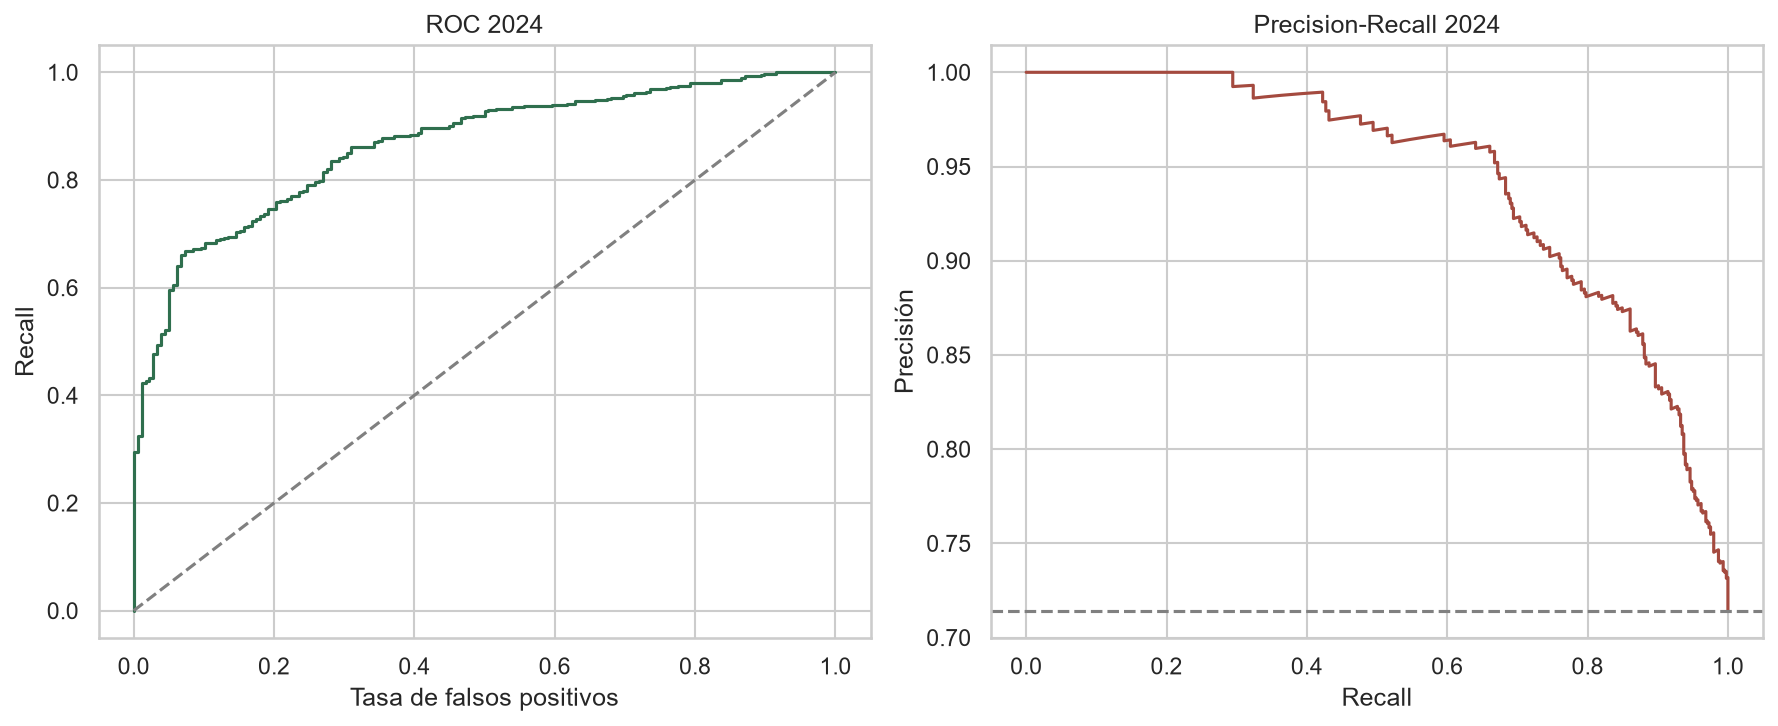

In [11]:
class_metrics = manifest["classification"]["holdout_2024"]
matrix = pd.DataFrame(
    class_metrics["confusion_matrix"],
    index=["Real bajo", "Real alto"],
    columns=["Predicho bajo", "Predicho alto"],
)
display(matrix)
display(pd.Series({key: class_metrics[key] for key in ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "mcc", "roc_auc", "pr_auc", "brier", "ece"]}, name="2024").round(4).to_frame())
print(f"Lectura crítica: {class_metrics['fn']} rendimientos altos quedaron clasificados como bajos y {class_metrics['fp']} bajos como altos.")
display(Image(filename=str(OUTPUT_DIR / "08_matriz_confusion_2024.png")))
display(Image(filename=str(OUTPUT_DIR / "09_curvas_roc_pr_2024.png")))

## 13. Backtest de regresores

SMOTE no se aplica al target continuo. Elastic Net, Random Forest y CatBoost se comparan con rendimiento `t-1` y media móvil de tres años.

,model,is_challenger,mean_mae,mean_rmse,mean_r2
0,catboost_regressor,True,0.2113,0.2911,-0.2894
4,random_forest_regressor,True,0.2142,0.2951,-0.2941
1,elastic_net,True,0.2273,0.2951,-0.2472
2,lag1,False,0.2287,0.3191,-0.6029
3,mean3,False,0.2444,0.3097,-0.3801


Regresor seleccionado sin mirar 2024: catboost_regressor


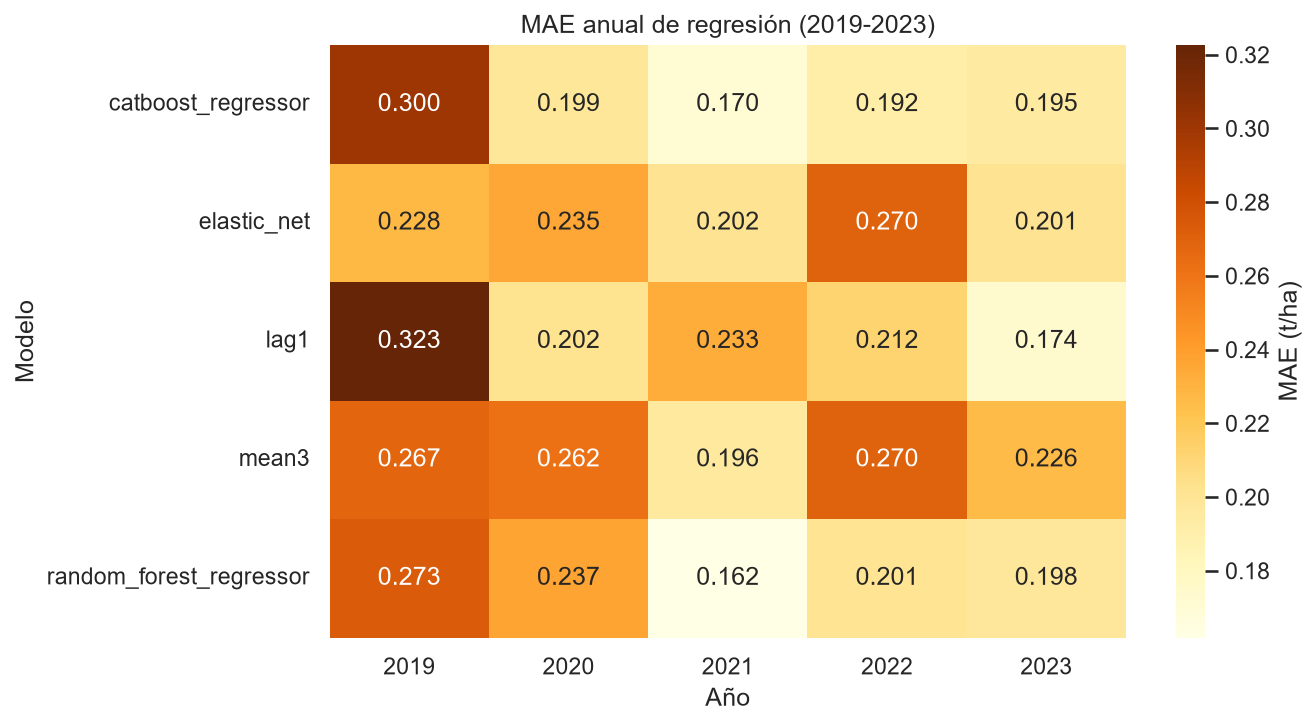

In [12]:
display(result["regression_summary"].sort_values("mean_mae").round(4))
print("Regresor seleccionado sin mirar 2024:", manifest["regression"]["winner"])
display(Image(filename=str(OUTPUT_DIR / "11_mae_modelo_anio.png")))

## 14. Evaluación final de regresión

MAE y RMSE están expresados en toneladas por hectárea. La compuerta exige mejorar el MAE del baseline `t-1` al menos 5%.

,2024
mae,0.2989
rmse,0.3614
r2,0.1472
lag1_mae,0.2479
mae_improvement_vs_lag1,-0.2055


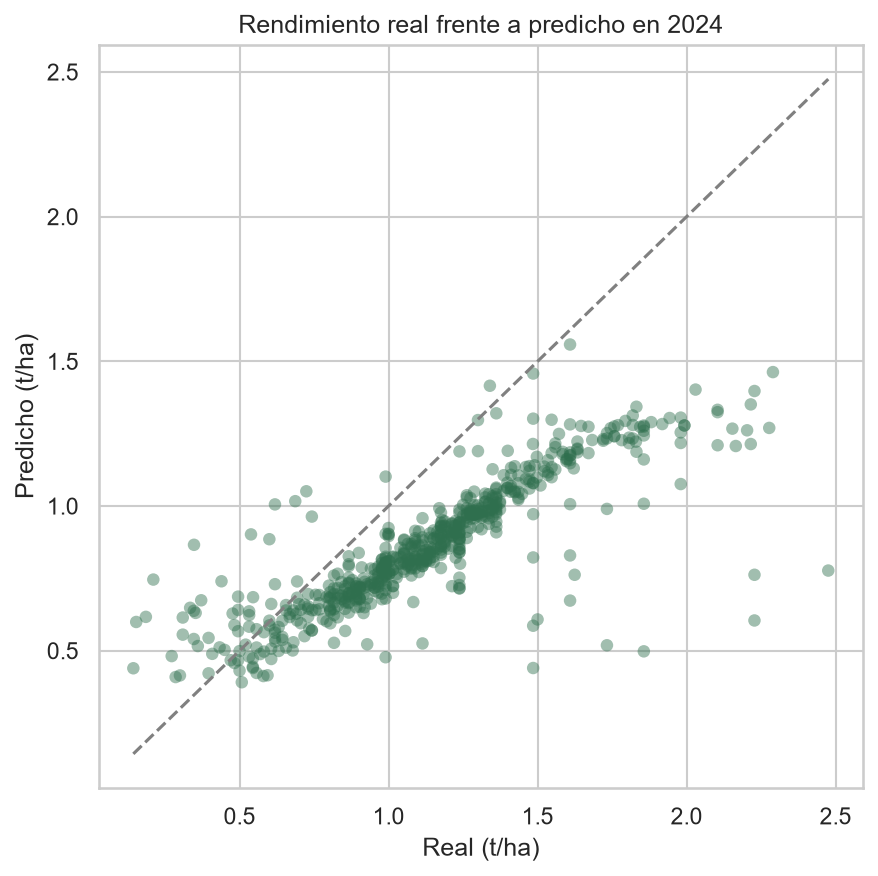

In [13]:
reg_metrics = manifest["regression"]["holdout_2024"]
display(pd.Series(reg_metrics, name="2024").round(4).to_frame())
display(Image(filename=str(OUTPUT_DIR / "12_real_vs_predicho_2024.png")))

## 15. Importancia de variables y errores

La importancia se calcula por permutación sobre 2024 para mantener un criterio común entre familias de modelos. No implica causalidad.

,feature,importance,importance_std
0,rendimiento_lag_1,0.3221,0.0250
1,municipio,0.0239,0.0165
2,area_cosechada_lag_1,0.0197,0.0036
3,area_sembrada_lag_1,0.0185,0.0072
4,produccion_lag_1,0.0076,0.0064
5,rendimiento_lag_3,0.0051,0.0045
6,departamento,0.0004,0.0087
7,lags_incompletos,0.0000,0.0000
8,anio,0.0000,0.0000
9,tendencia_rendimiento_3y,-0.0053,0.0060


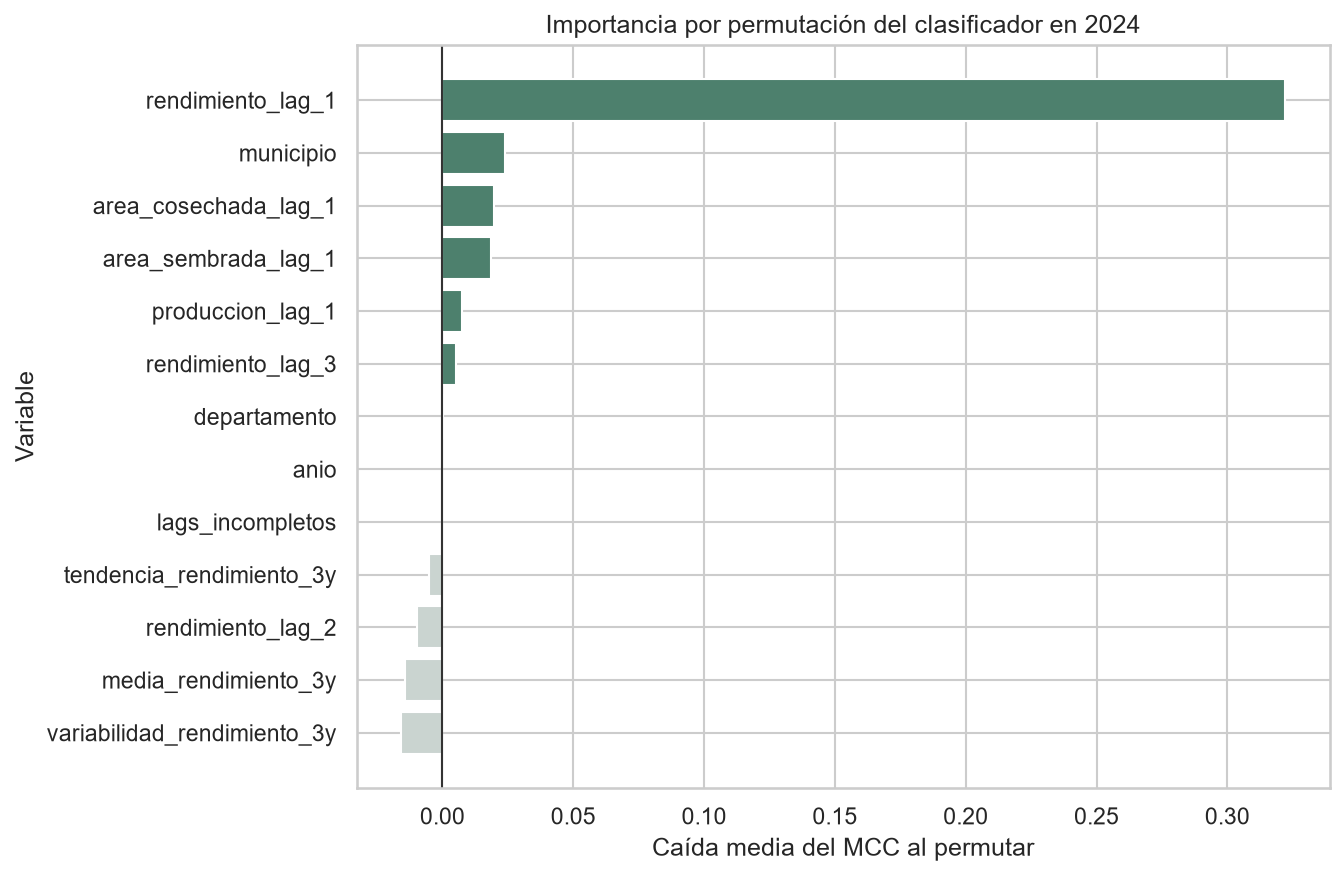

In [14]:
importance = pd.read_csv(OUTPUT_DIR / "importancia_variables.csv")
display(importance.round(4))
display(Image(filename=str(OUTPUT_DIR / "13_importancia_variables.png")))

## 16. Compuerta de producción y limitaciones

El modelo solo recibe estado `production_candidate` si supera simultáneamente los siete controles predefinidos. Un buen resultado aislado no compensa inestabilidad o falta de mejora frente a baselines.

In [15]:
gate_table = pd.DataFrame(manifest["gate"]["checks"])
display(gate_table)
print("ESTADO FINAL:", manifest["status"])
if manifest["gate"]["failed_checks"]:
    print("Razones para no aprobar:")
    for reason in manifest["gate"]["failed_checks"]:
        print("-", reason)
else:
    print("El candidato superó todos los criterios definidos; aún requiere monitoreo de drift y revisión agronómica.")

,name,passed,failure_reason
0,integridad_datos,True,Falló la integridad de datos.
1,mejora_mcc_vs_lag1,False,El MCC promedio no supera al baseline t-1 por ...
2,mcc_anual_no_negativo,True,Existe al menos un año de selección con MCC ne...
3,mcc_holdout,False,El MCC 2024 es inferior a 0.50.
4,balanced_accuracy_holdout,False,La balanced accuracy 2024 es inferior a 0.70.
5,mejora_mae_regresion,False,La regresión no mejora al baseline t-1 al meno...
6,brier_vs_prevalencia,True,El Brier calibrado no mejora la probabilidad c...


ESTADO FINAL: experimental_not_approved
Razones para no aprobar:
- El MCC promedio no supera al baseline t-1 por al menos 0.02.
- El MCC 2024 es inferior a 0.50.
- La balanced accuracy 2024 es inferior a 0.70.
- La regresión no mejora al baseline t-1 al menos 5% en MAE 2024.


## 17. Exportación y resumen final

Se guardan modelos de evaluación, modelos operativos reentrenados hasta 2024, calibrador, manifiesto, model card, predicciones fuera de muestra, tablas y las 13 figuras. El manifiesto conserva las métricas del modelo evaluado hasta 2023; no las sustituye por resultados del reentrenamiento operativo.

In [16]:
artifacts = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
print(f"Estado: {manifest['status']}")
print(f"Artefactos generados: {len(artifacts)}")
display(pd.DataFrame({"archivo": artifacts}))
print("Uso válido: priorización de rendimiento y riesgo productivo con revisión humana.")
print("Uso inválido: afirmar rentabilidad o aprobar automáticamente crédito/inversión.")

Estado: experimental_not_approved
Artefactos generados: 32


,archivo
0,01_distribucion_rendimiento.png
1,02_boxplot_rendimiento_anio.png
2,03_faltantes_variables.png
3,04_balance_clase_anio.png
4,05_smotenc_antes_despues.png
5,06_modelos_mcc_balanced_accuracy.png
6,07_mcc_anual.png
7,08_matriz_confusion_2024.png
8,09_curvas_roc_pr_2024.png
9,10_calibracion_2024.png


Uso válido: priorización de rendimiento y riesgo productivo con revisión humana.
Uso inválido: afirmar rentabilidad o aprobar automáticamente crédito/inversión.
